# Часть 1

## Этап 1

In [1]:
import os
import numpy as np
import pandas as pd
import mlflow
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from dotenv import load_dotenv
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier)
from sklearn.metrics import roc_auc_score

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import confint_proportions_2indep

from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k
from causalml.inference.meta import BaseTRegressor, BaseXRegressor, BaseRRegressor

/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = Path.cwd()
load_dotenv(PROJECT_ROOT / ".env")

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5001
MLFLOW_TRACKING_URI = f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = os.getenv("S3_ENDPOINT_URL", "https://storage.yandexcloud.net")

EXPERIMENT_NAME_STAGE_3 = "UPLIFT_STAGE_3_MODEL_COMPARE"
EXPERIMENT_NAME_STAGE_4 = "UPLIFT_STAGE_4_TUNING"

ASSETS_DIR = PROJECT_ROOT / "assets_uplift"
STAGE3_DIR = ASSETS_DIR / "stage3_model_compare"
STAGE4_DIR = ASSETS_DIR / "stage4_tuning"

for stage_dir in [STAGE3_DIR, STAGE4_DIR]:
    stage_dir.mkdir(parents=True, exist_ok=True)


def init_mlflow(experiment_name: str) -> None:
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    mlflow.set_registry_uri(MLFLOW_TRACKING_URI)
    mlflow.set_experiment(experiment_name)

In [3]:
df = pd.read_csv('uplift_fp_data.csv')

print(f"shape: {df.shape[0]:,} x {df.shape[1]}")
print(f"\nindex: {type(df.index).__name__} | unique={df.index.is_unique} | monotonic={df.index.is_monotonic_increasing}")
print(df.info())
display(df.head(5))

shape: 64,000 x 10

index: RangeIndex | unique=True | monotonic=True
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  int64  
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  int64  
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  int64  
 8   treatment        64000 non-null  int64  
 9   target           64000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 4.9 MB
None


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.44,1,0,1,0,1,1,0
1,6,2,329.08,1,1,2,1,2,0,0
2,7,1,180.65,0,1,1,1,2,1,0
3,9,4,675.83,1,0,2,1,2,0,0
4,2,0,45.34,1,0,0,0,2,1,0


## Этап 2

### EDA


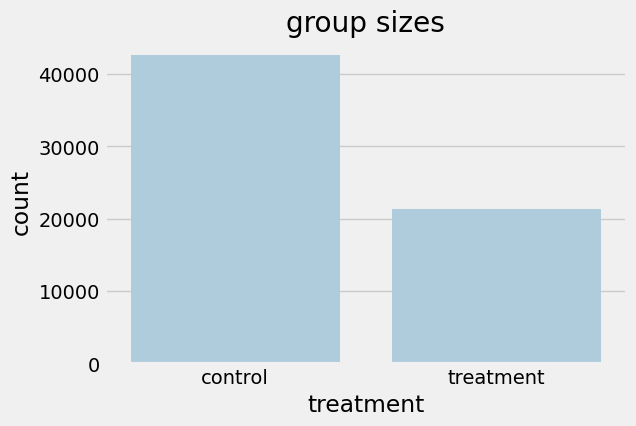

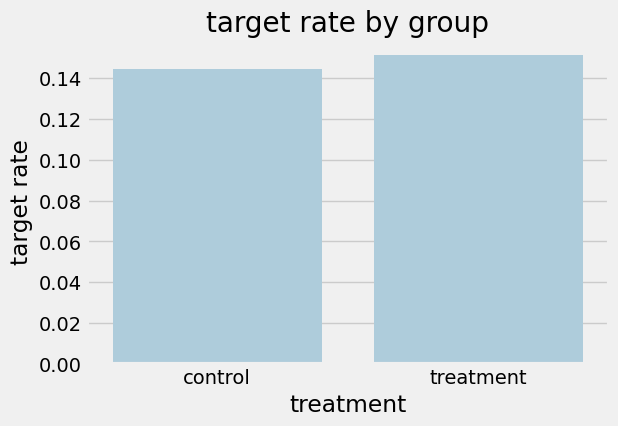

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="treatment")
plt.title("group sizes")
plt.xticks([0, 1], ["control", "treatment"])
plt.xlabel("treatment")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="treatment", y="target", errorbar=None)
plt.title("target rate by group")
plt.xticks([0, 1], ["control", "treatment"])
plt.xlabel("treatment")
plt.ylabel("target rate")
plt.show()

In [5]:
control = df[df["treatment"] == 0]
treat = df[df["treatment"] == 1]

n_control = int(len(control))
n_treat = int(len(treat))

x_control = int(control["target"].sum())
x_treat = int(treat["target"].sum())

p_control = x_control / n_control
p_treat = x_treat / n_treat
uplift_raw = p_treat - p_control

print(f"control size: {n_control:,}")
print(f"treatment size: {n_treat:,}")
print(f"control rate: {p_control:.6f} ({x_control}/{n_control})")
print(f"treatment rate: {p_treat:.6f} ({x_treat}/{n_treat})")
print(f"uplift (diff in rates): {uplift_raw:.6f}")

cont = pd.DataFrame(
    {0: [n_control - x_control, n_treat - x_treat], 1: [x_control, x_treat]},
    index=pd.Index([0, 1], name="treatment")
)
cont.columns.name = "target"

print("\ncontingency table:")
print(cont.to_string())

control size: 42,613
treatment size: 21,387
control rate: 0.144463 (6156/42613)
treatment rate: 0.151400 (3238/21387)
uplift (diff in rates): 0.006937

contingency table:
target         0     1
treatment             
0          36457  6156
1          18149  3238


**EDA SUMMARY**

All columns have no missing values, and the index is clean.

`treatment` and `target` are binary variables, so the task is to compare the success rates (target=1) between two independent groups (control vs treatment). 

The experiment groups are unequal in size: control = 42,613 and treatment = 21,387 (~2:1).

The overall response rate is higher in treatment than in control: 0.1514 vs 0.1445, giving an average uplift of +0.00694 (~+0.69 percentage points).

The contingency table shows sufficient counts in all cells (no sparse cells), so standard proportion-based tests are applicable.

The average treatment effect is small, so the main value of uplift modeling is expected to come from ranking users, not from applying treatment to everyone.




# Этап 2

### Проверка на статистическую значимость

In [6]:
chi2, p_value, dof, expected = chi2_contingency(cont)
min_expected = float(np.min(expected))

print(f"chi2 p-value: {p_value:.4g}")
print(f"min expected cell count: {min_expected:.3f}")

ci_low, ci_high = confint_proportions_2indep(
    count1=x_treat, nobs1=n_treat,
    count2=x_control, nobs2=n_control,
    method="score"
)

print(f"uplift 95% ci: [{ci_low:.4f}, {ci_high:.4f}]")

chi2 p-value: 0.01994
min expected cell count: 3139.211
uplift 95% ci: [0.0011, 0.0128]


**TEST CHOICE JUSTIFICATION**

Uplift 95% CI [0.0011; 0.0128] - small but non-zero average treatment effect.
 
Since both treatment and target are binary, the effect can be tested by comparing response rates between two independent groups using a 2×2 contingency table and a chi-square test of independence. The chi-square approximation is valid here because expected cell counts are very large.

p-value < 0.05 -- effect has a statistically significant (but with a large sample size even small effects can become statistically significant)

## Построение корреляций

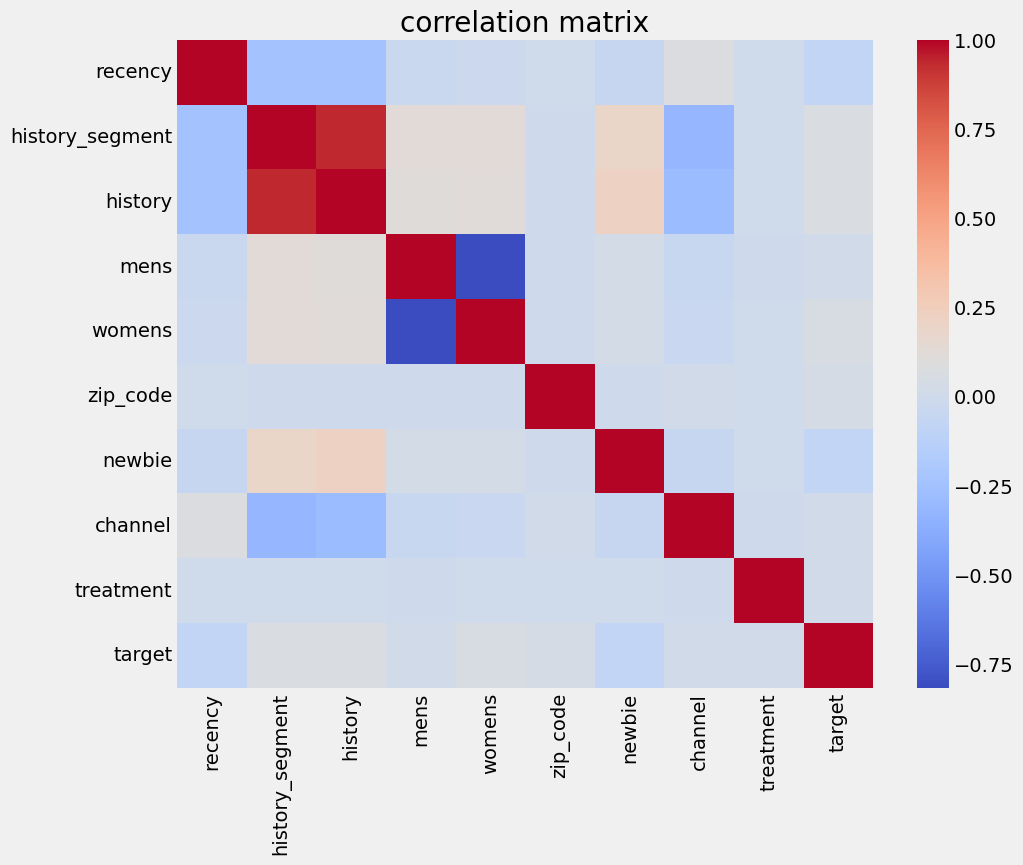

top correlations with target:
target             1.000000
history_segment    0.069734
history            0.065153
womens             0.051999
zip_code           0.037570
channel            0.010584
treatment          0.009247
mens               0.006712
newbie            -0.073924
recency           -0.074765


In [7]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("correlation matrix")
plt.show()

corr_with_target = corr_matrix["target"].sort_values(ascending=False)
print("top correlations with target:")
print(corr_with_target.head(10).to_string())

**CORRELATIONS**

The correlations with the `target` are generally weak (all absolute values are below 0.1), which means no single feature has a strong linear relationship with the target. The strongest positive correlations are `history_segment`, `history`, and `womens`, while the strongest negative correlations are `recency` and `newbie`, but all of them are still relatively small.

## Этап 3

In [8]:
feature_names = [c for c in df.columns if c not in ["target", "treatment"]]
categorical_features = [c for c in ["zip_code", "channel", "history_segment"] if c in feature_names]
numeric_features = [c for c in feature_names if c not in categorical_features]

def calc_smd(control_series: pd.Series, treat_series: pd.Series) -> float:
    pooled_std = np.sqrt((float(control_series.var(ddof=1)) + float(treat_series.var(ddof=1))) / 2)
    if pooled_std == 0:
        return 0.0
    return float((float(treat_series.mean()) - float(control_series.mean())) / pooled_std)

def calc_cramers_v(table_2d: pd.DataFrame) -> float:
    chi2_local, _, _, _ = chi2_contingency(table_2d)
    n = int(table_2d.to_numpy().sum())
    rows, cols = table_2d.shape
    k = min(rows, cols)
    if n == 0 or k <= 1:
        return 0.0
    return float(np.sqrt(chi2_local / (n * (k - 1))))

balance_rows = []

for col in numeric_features:
    balance_rows.append({"feature": col, "metric": "smd", "value": abs(calc_smd(control[col], treat[col]))})

for col in categorical_features:
    contingency_table = pd.crosstab(df["treatment"], df[col])
    balance_rows.append({"feature": col, "metric": "cramers_v", "value": calc_cramers_v(contingency_table)})

balance = pd.DataFrame(balance_rows).sort_values("value", ascending=False)

print("top imbalance signals:")
print(balance.head(10).to_string(index=False))

smd_bad_count = int(((balance["metric"] == "smd") & (balance["value"] >= 0.1)).sum())
v_bad_count = int(((balance["metric"] == "cramers_v") & (balance["value"] >= 0.05)).sum())

print(f"\nfeatures with |smd| >= 0.1: {smd_bad_count}")
print(f"categorical with v >= 0.05: {v_bad_count}")

top imbalance signals:
        feature    metric    value
history_segment cramers_v 0.009459
           mens       smd 0.006339
        channel cramers_v 0.006041
         newbie       smd 0.003003
        history       smd 0.002646
       zip_code cramers_v 0.002322
        recency       smd 0.001762
         womens       smd 0.001152

features with |smd| >= 0.1: 0
categorical with v >= 0.05: 0


In [9]:
X_prop = df[feature_names].copy()
t_prop = df["treatment"].astype(int)

X_prop_train, X_prop_valid, t_prop_train, t_prop_valid = train_test_split(
    X_prop, t_prop, test_size=0.2, random_state=42, stratify=t_prop
)

propensity_model = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)
propensity_model.fit(X_prop_train, t_prop_train)

t_prop_score = propensity_model.predict_proba(X_prop_valid)[:, 1]
propensity_auc = roc_auc_score(t_prop_valid, t_prop_score)

print(f"propensity auc: {propensity_auc:.4f}")

propensity auc: 0.5012


**MODEL CHOICE**

The imbalance checks show that the treatment and control groups are essentially the same (max `SMD` ~0.006, max `Cramer's V` ~0.009), and the `propensity AUC` ~0.50 confirms that treatment assignment is close to random, so the uplift signal is not driven by group differences and no strong propensity correction is needed. Therefore, `T-learner` is used as a simple baseline, `X-learner` is tested as a strong option for unequal group sizes (~2:1), and and `R-learner` is added as a third comparison because it models uplift more directly (separating the baseline outcome from the treatment effect), which can improve ranking stability.

### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг
#### Пример использования маппинга
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

### Разбиение выборки на тренировочную и тестовую

In [10]:
X = df.drop(columns=["target", "treatment"])
y = df["target"].astype(int)
treatment = df["treatment"].astype(int)

stratify_key = treatment.astype(str) + "_" + y.astype(str)

X_train, X_test, y_train, y_test, treatment_train, treatment_test = train_test_split(
    X, y, treatment,
    test_size=0.2,
    random_state=42,
    stratify=stratify_key
)

print(f"train size: {X_train.shape[0]:,}")
print(f"test size: {X_test.shape[0]:,}")

treatment_mapping = {0: "control", 1: "treatment"}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)

train size: 51,200
test size: 12,800


In [11]:
base_params = {
    "n_estimators": 500,
    "min_samples_leaf": 50,
    "random_state": 42,
    "n_jobs": -1
}

def make_base_regressor() -> RandomForestRegressor:
    return RandomForestRegressor(**base_params)

def compute_metrics(model_name: str, uplift_pred: np.ndarray) -> dict:
    uplift_pred = np.asarray(uplift_pred).squeeze()
    return {
        "model": model_name,
        "uplift_auc": float(uplift_auc_score(y_test, uplift_pred, treatment_test)),
        "qini_auc": float(qini_auc_score(y_test, uplift_pred, treatment_test)),
        "uplift_at_30": float(uplift_at_k(y_test, uplift_pred, treatment_test, k=0.3, strategy="overall")),
        "propensity_auc": float(propensity_auc)
    }

### Обучение выбранного бейзлайна

In [12]:
t_learner = BaseTRegressor(learner=make_base_regressor(), control_name=0)
t_learner.fit(X_train.values, treatment_train.values, y_train.values)
t_pred = t_learner.predict(X_test.values).squeeze()

### Расчет метрик для выбранного бейзлайна на тестовой выборке

In [13]:
t_metrics = compute_metrics("t_learner_baseline", t_pred)
print("baseline metrics:")
print(pd.DataFrame([t_metrics]).to_string(index=False))

baseline metrics:
             model  uplift_auc  qini_auc  uplift_at_30  propensity_auc
t_learner_baseline    0.025543  0.058554      0.050924        0.501162


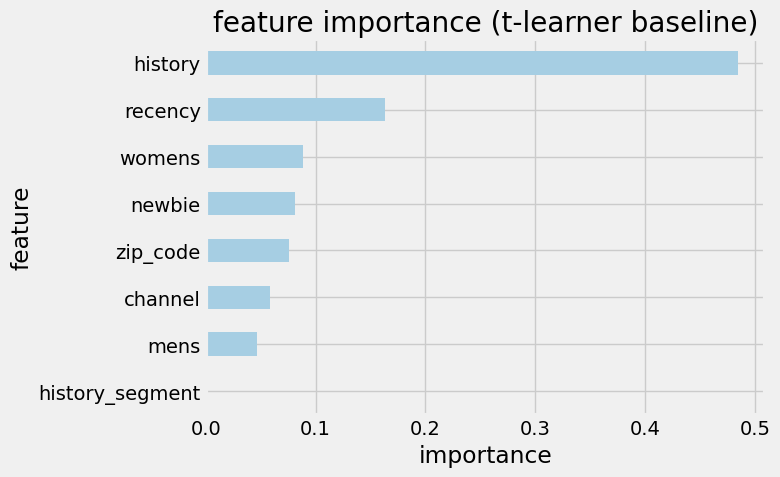

In [14]:
treatment_group = 1

control_model = t_learner.models_c[treatment_group]
treat_model = t_learner.models_t[treatment_group]

importance_mean = (control_model.feature_importances_ + treat_model.feature_importances_) / 2
importance = pd.Series(importance_mean, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importance.head(15).sort_values().plot(kind="barh")
plt.title("feature importance (t-learner baseline)")
plt.xlabel("importance")
plt.ylabel("feature")
plt.tight_layout()
plt.show()

# Обучение 2 моделей 

### Обучение модели 1

In [15]:
x_learner = BaseXRegressor(learner=make_base_regressor(), control_name=0)
x_learner.fit(X_train.values, treatment_train.values, y_train.values)

x_pred = x_learner.predict(X_test.values).squeeze()
print("x-learner trained")

/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-pack

x-learner trained


### Получение метрик по модели 1

In [16]:
x_metrics = compute_metrics("x_learner", x_pred)
print("model 1 metrics:")
print(pd.DataFrame([x_metrics]).to_string(index=False))

model 1 metrics:
    model  uplift_auc  qini_auc  uplift_at_30  propensity_auc
x_learner    0.029839   0.06677      0.052519        0.501162


### Обучение модели 2

In [17]:
r_learner = BaseRRegressor(
    learner=make_base_regressor(),
    control_name=0, n_fold=5,
    random_state=42
)

r_learner.fit(X_train.values, treatment_train.values, y_train.values, p=None, verbose=False)

r_pred = r_learner.predict(X_test.values).squeeze()
print("r-learner trained")

/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-pack

r-learner trained


### Получение метрик по модели 2

In [18]:
r_metrics = compute_metrics("r_learner", r_pred)
print("model 2 metrics:")
print(pd.DataFrame([r_metrics]).to_string(index=False))

model 2 metrics:
    model  uplift_auc  qini_auc  uplift_at_30  propensity_auc
r_learner    0.023077  0.051333       0.03322        0.501162


In [19]:
results = pd.DataFrame([t_metrics, x_metrics, r_metrics]).sort_values(by=["uplift_at_30", "qini_auc", "uplift_auc"], ascending=False)

print("model comparison:")
print(results.to_string(index=False))

model comparison:
             model  uplift_auc  qini_auc  uplift_at_30  propensity_auc
         x_learner    0.029839  0.066770      0.052519        0.501162
t_learner_baseline    0.025543  0.058554      0.050924        0.501162
         r_learner    0.023077  0.051333      0.033220        0.501162


**MODEL COMPARISON**

The `X-learner` is the best: it has the highest uplift@30% (0.0525) and also the best overall uplift ranking scores (`qini AUC` and `uplift AUC`).
The `T-learner` is close but slightly worse, and the `R-learner` is clearly the weakest.

The `propensity AUC` (~0.50) indicates that the treatment assignment is close to random and is not predictable from the features, so uplift evaluation is more reliable and there is no strong need to rely on propensity-based correction.

Final choice: `X-learner` for the next stage.

In [20]:
init_mlflow(EXPERIMENT_NAME_STAGE_3)

comparison_path = STAGE3_DIR / "model_comparison.csv"
balance_path = STAGE3_DIR / "balance_top10.csv"
importance_path = STAGE3_DIR / "feature_importance_t_learner.png"

results.to_csv(comparison_path, index=False)
balance.head(10).to_csv(balance_path, index=False)

plt.figure(figsize=(8, 5))
importance.head(15).sort_values().plot(kind="barh")
plt.title("feature importance (t-learner baseline)")
plt.xlabel("importance")
plt.ylabel("feature")
plt.tight_layout()
plt.savefig(importance_path, dpi=150)
plt.close()

def log_stage3_run(run_name: str, model_obj, uplift_pred: np.ndarray) -> None:
    metrics = compute_metrics(run_name, uplift_pred)
    metrics_to_log = {k: v for k, v in metrics.items() if k != "model"}

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(base_params)
        mlflow.log_metrics(metrics_to_log)

        mlflow.log_artifact(str(comparison_path))
        mlflow.log_artifact(str(balance_path))
        mlflow.log_artifact(str(importance_path))

        model_path = STAGE3_DIR / f"{run_name}.joblib"
        joblib.dump(model_obj, model_path)
        mlflow.log_artifact(str(model_path))

        print(f"mlflow logged: {run_name}")


log_stage3_run("t_learner_baseline", t_learner, t_pred)
log_stage3_run("x_learner", x_learner, x_pred)
log_stage3_run("r_learner", r_learner, r_pred)

mlflow logged: t_learner_baseline
🏃 View run t_learner_baseline at: http://127.0.0.1:5001/#/experiments/16/runs/7ffd5d7635c44ab4923ce9c8370d076e
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/16
mlflow logged: x_learner
🏃 View run x_learner at: http://127.0.0.1:5001/#/experiments/16/runs/96204004dc0146a489decb0c136b9a04
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/16
mlflow logged: r_learner
🏃 View run r_learner at: http://127.0.0.1:5001/#/experiments/16/runs/b69e21a7af7d44249c083ca57e541361
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/16


# Часть 2

## Этап 1
Улучшите бейзлайн выбранной модели

In [21]:
X_train_fe = pd.get_dummies(X_train, columns=categorical_features)
X_test_fe = pd.get_dummies(X_test, columns=categorical_features)

X_test_fe = X_test_fe.reindex(columns=X_train_fe.columns, fill_value=0)

print(f"train fe shape: {X_train_fe.shape}")
print(f"test fe shape: {X_test_fe.shape}")

ohe_feature_columns = X_train_fe.columns.tolist()

train fe shape: (51200, 18)
test fe shape: (12800, 18)


#### Генерация признаков (опционально)

In [22]:
def add_feature_engineering(X: pd.DataFrame) -> pd.DataFrame:
    X_new = X.copy()

    X_new["history_log"] = np.log1p(X_new["history"])
    X_new["history_per_recency"] = X_new["history"] / (X_new["recency"] + 1.0)
    X_new["recency_x_newbie"] = X_new["recency"] * X_new["newbie"]
    X_new["history_x_newbie"] = X_new["history"] * X_new["newbie"]
    X_new["history_x_mens"] = X_new["history"] * X_new["mens"]
    X_new["history_x_womens"] = X_new["history"] * X_new["womens"]
    X_new["mens_only"] = ((X_new["mens"] == 1) & (X_new["womens"] == 0)).astype(int)
    X_new["womens_only"] = ((X_new["womens"] == 1) & (X_new["mens"] == 0)).astype(int)
    X_new["both_categories"] = ((X_new["mens"] == 1) & (X_new["womens"] == 1)).astype(int)

    return X_new


X_train_eng = add_feature_engineering(X_train)
X_test_eng = add_feature_engineering(X_test)

X_train_fe = pd.get_dummies(X_train_eng, columns=categorical_features)
X_test_fe = pd.get_dummies(X_test_eng, columns=categorical_features)
X_test_fe = X_test_fe.reindex(columns=X_train_fe.columns, fill_value=0)

ohe_feature_columns = X_train_fe.columns.tolist()

print(f"train fe shape: {X_train_fe.shape}")
print(f"test fe shape:  {X_test_fe.shape}")

train fe shape: (51200, 27)
test fe shape:  (12800, 27)


### Подбор гиперпараметров

In [23]:
def cv_uplift_score(params: dict, X_full: pd.DataFrame, y_full: pd.Series, treatment_full: pd.Series, n_splits: int = 3) -> float:
    stratify_key = treatment_full.astype(str) + "_" + y_full.astype(str)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    scores = []
    for train_idx, val_idx in skf.split(X_full, stratify_key):
        X_tr = X_full.iloc[train_idx]
        X_val = X_full.iloc[val_idx]
        y_tr = y_full.iloc[train_idx]
        y_val = y_full.iloc[val_idx]
        t_tr = treatment_full.iloc[train_idx]
        t_val = treatment_full.iloc[val_idx]

        learner = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
        model = BaseXRegressor(learner=learner, control_name=0)
        model.fit(X_tr.values, t_tr.values, y_tr.values)

        pred = np.asarray(model.predict(X_val.values)).squeeze()
        score = uplift_at_k(y_val, pred, t_val, k=0.3, strategy="overall")
        scores.append(float(score))

    return float(np.mean(scores))


def objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 400, 700),
        "max_depth": trial.suggest_int("max_depth", 5, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 40, 120),
        "max_features": trial.suggest_float("max_features", 0.5, 1.0),
    }
    return cv_uplift_score(params, X_train_fe, y_train, treatment_train)


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"best uplift@30 (3-fold cv): {study.best_value:.6f}")
print(f"best params: {study.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-proje

best uplift@30 (3-fold cv): 0.045160
best params: {'n_estimators': 447, 'max_depth': 5, 'min_samples_leaf': 86, 'max_features': 0.5736494341677157}


In [24]:
best_params = study.best_params

best_regressor = RandomForestRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"],
    random_state=42,
    n_jobs=-1
)

x_learner_tuned = BaseXRegressor(learner=best_regressor, control_name=0)
x_learner_tuned.fit(X_train_fe.values, treatment_train.values, y_train.values)

uplift_pred_test = np.asarray(x_learner_tuned.predict(X_test_fe.values)).squeeze()
final_metrics = compute_metrics("x_learner_tuned_rf", uplift_pred_test)

print("\ntuned test model:")
print(pd.DataFrame([final_metrics]).to_string(index=False))
print("\baseline test x-learner")
print(pd.DataFrame([x_metrics]).to_string(index=False))

delta_uplift = final_metrics["uplift_at_30"] - x_metrics["uplift_at_30"]
delta_qini = final_metrics["qini_auc"] - x_metrics["qini_auc"]

print(f"\nuplift@30 delta: {delta_uplift:+.6f}")
print(f"qini_auc delta:  {delta_qini:+.6f}")

/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-pack

/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-pack


tuned test model:
             model  uplift_auc  qini_auc  uplift_at_30  propensity_auc
x_learner_tuned_rf    0.030287  0.067623      0.056456        0.501162
aseline test x-learner
    model  uplift_auc  qini_auc  uplift_at_30  propensity_auc
x_learner    0.029839   0.06677      0.052519        0.501162

uplift@30 delta: +0.003937
qini_auc delta:  +0.000852


In [25]:
init_mlflow(EXPERIMENT_NAME_STAGE_4)

trials_path = STAGE4_DIR / "optuna_trials.csv"
study.trials_dataframe().to_csv(trials_path, index=False)

model_path = STAGE4_DIR / "x_learner_tuned.joblib"
joblib.dump(x_learner_tuned, model_path)

cols_path = STAGE4_DIR / "ohe_feature_columns.joblib"
joblib.dump(ohe_feature_columns, cols_path)

test_metrics = {k: v for k, v in final_metrics.items() if k != "model"}
test_metrics_for_mlflow = {f"{key}_test": value for key, value in test_metrics.items()}
metrics_to_log = {"best_uplift_at_30_cv": float(study.best_value), **test_metrics_for_mlflow}

with mlflow.start_run(run_name="x_learner_rf_optuna"):
    mlflow.log_params(study.best_params)
    mlflow.log_metrics(metrics_to_log)

    mlflow.log_artifact(str(trials_path))
    mlflow.log_artifact(str(model_path))
    mlflow.log_artifact(str(cols_path))

    print("mlflow logged: x_learner_rf_optuna")

mlflow logged: x_learner_rf_optuna
🏃 View run x_learner_rf_optuna at: http://127.0.0.1:5001/#/experiments/17/runs/3a8fce4a07fc4a29bd570f810b85c372
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/17


## Этап 2

### Визуализация результатов

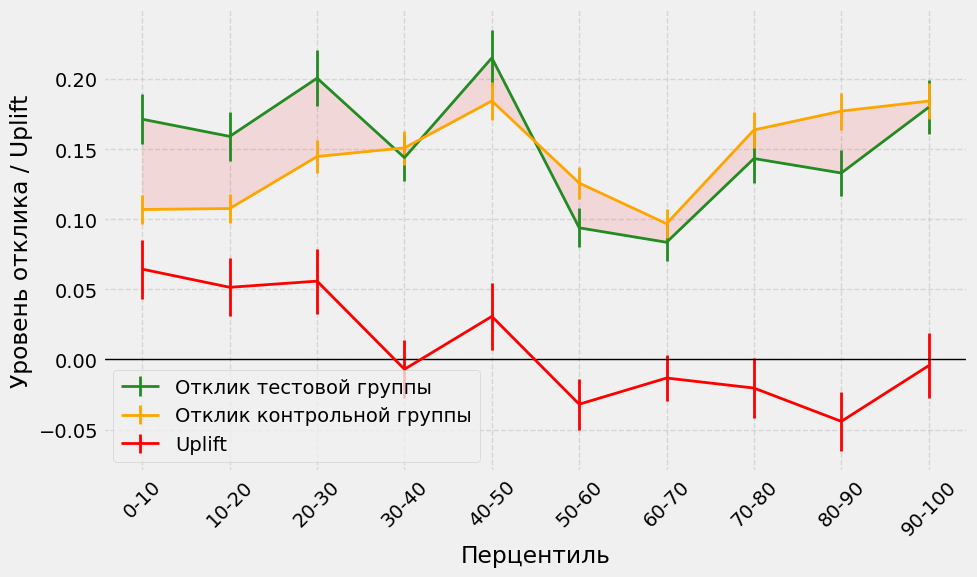

In [26]:
from utils import custom_uplift_by_percentile

custom_uplift_by_percentile(y_true=y_test, uplift=uplift_pred_test, treatment=treatment_test)
plt.show()

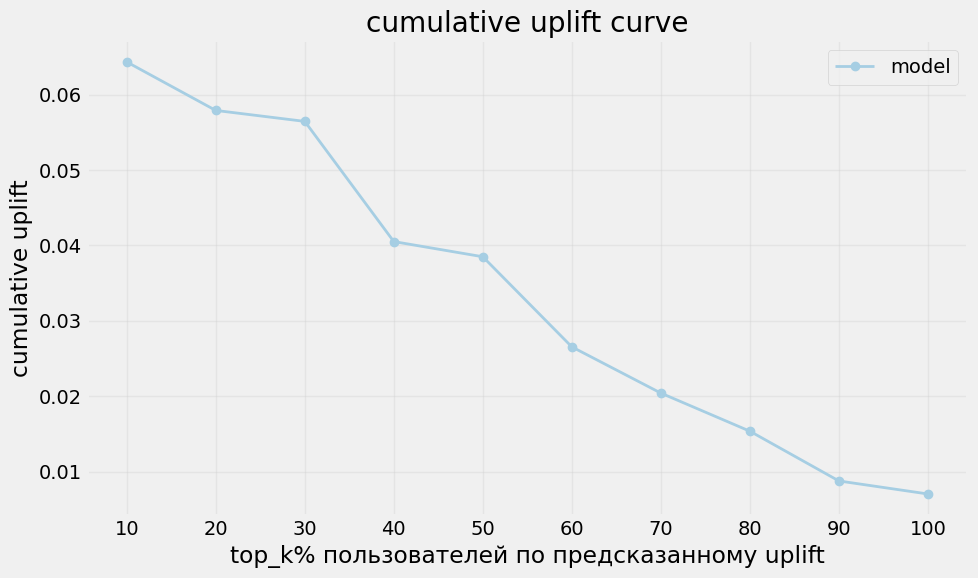

In [27]:
n_bins = 10
order = np.argsort(-uplift_pred_test)

y_sorted = y_test.values[order]
t_sorted = treatment_test.values[order]

cum_uplift = []
for i in range(1, n_bins + 1):
    idx = int(len(y_sorted) * i / n_bins)
    y_bin = y_sorted[:idx]
    t_bin = t_sorted[:idx]

    treat_mask = t_bin == 1
    control_mask = t_bin == 0

    if treat_mask.sum() > 0 and control_mask.sum() > 0:
        rate_t = y_bin[treat_mask].mean()
        rate_c = y_bin[control_mask].mean()
        cum_uplift.append(rate_t - rate_c)
    else:
        cum_uplift.append(0.0)

percentiles = [i * 10 for i in range(1, n_bins + 1)]

plt.figure(figsize=(10, 6))
plt.plot(percentiles, cum_uplift, marker="o", linewidth=2, label="model")
plt.xlabel("top_k% пользователей по предсказанному uplift")
plt.ylabel("cumulative uplift")
plt.title("cumulative uplift curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(percentiles)
plt.tight_layout()
plt.show()

**MODEL QUALITY AND `uplift-by-percentile` INTERPRETATION**

The `cumulative uplift` curve is highest for the top-ranked users (best around the top 10%) and drops as we include more people, so model puts the users who benefit most from the treatment at the top, while the average benefit becomes smaller for lower ranked users.

The `uplift-by-percentile` plot shows that the treatment effect is not the same for everyone. It is positive in the top 20–30% (treatment works better than control there), but close to zero or even negative in the middle and lower percentiles (treatment has little effect or can hurt).

# Этап 3

In [28]:
class UpliftModelInference:

    def __init__(self, model, feature_names, logger=None, categorical_cols=None,
                 ohe_feature_columns=None, fe_func=None):
        self.model = model
        self.feature_names = list(feature_names)
        self.logger = logger
        self.fe_func = fe_func

        self.categorical_cols = list(categorical_cols) if categorical_cols is not None else []
        self.ohe_feature_columns = list(ohe_feature_columns) if ohe_feature_columns is not None else None

        if self.logger:
            self.logger.info(f"uplift model initialized, features: {self.feature_names}")
            if self.ohe_feature_columns is not None:
                self.logger.info(f"ohe enabled, ohe columns count: {len(self.ohe_feature_columns)}")

    def _transform_data(self, X: pd.DataFrame) -> pd.DataFrame:
        if self.logger:
            self.logger.debug(f"input shape before transform: {X.shape}")

        X_prepared = X[self.feature_names].copy()

        if self.fe_func is not None:
            X_prepared = self.fe_func(X_prepared)

        if self.ohe_feature_columns is None or not self.categorical_cols:
            return X_prepared

        X_encoded = pd.get_dummies(X_prepared, columns=self.categorical_cols)
        X_encoded = X_encoded.reindex(columns=self.ohe_feature_columns, fill_value=0)

        if self.logger:
            self.logger.debug(f"input shape after ohe: {X_encoded.shape}")

        return X_encoded

    def predict(self, X: pd.DataFrame):
        if X is None or X.empty:
            if self.logger:
                self.logger.error("empty dataframe provided")
            return None

        if X.isnull().any().any():
            if self.logger:
                self.logger.error("input contains missing values")
            return [None] * len(X)

        missing_features = sorted(set(self.feature_names) - set(X.columns))
        if missing_features:
            error_msg = f"missing features: {missing_features}"
            if self.logger:
                self.logger.error(error_msg)
            return [None] * len(X)

        if self.logger:
            self.logger.info(f"running prediction for shape: {X.shape}")

        X_transformed = self._transform_data(X)

        if self.logger:
            self.logger.debug("calling model.predict")

        uplift = np.asarray(self.model.predict(X_transformed.values)).squeeze()

        if self.logger:
            self.logger.info("prediction finished")

        return uplift

In [29]:
model = UpliftModelInference(
    model=x_learner_tuned,
    feature_names=feature_names,
    categorical_cols=categorical_features,
    ohe_feature_columns=ohe_feature_columns,
    fe_func=add_feature_engineering
)

In [30]:
test_data = pd.DataFrame({
    'recency': [1, 2, 3],
    'history_segment': [1, 2, 3], 
    'history': [100, 200, 300],
    'mens': [1, 0, 1],
    'womens': [0, 1, 0],
    'zip_code': [1, 0, 1],
    'newbie': [0, 1, 0],
    'channel': [1, 2, 0]
})

In [31]:
pred = model.predict(test_data)
print("inference uplift:", pred)

inference uplift: [-0.03581541  0.00236548 -0.03274044]
